In [6]:
# Cell 1: Setup
from graphviz import Digraph
from IPython.display import Image
from micrograd.engine import Value

In [17]:
# Cell 2: Visualization
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

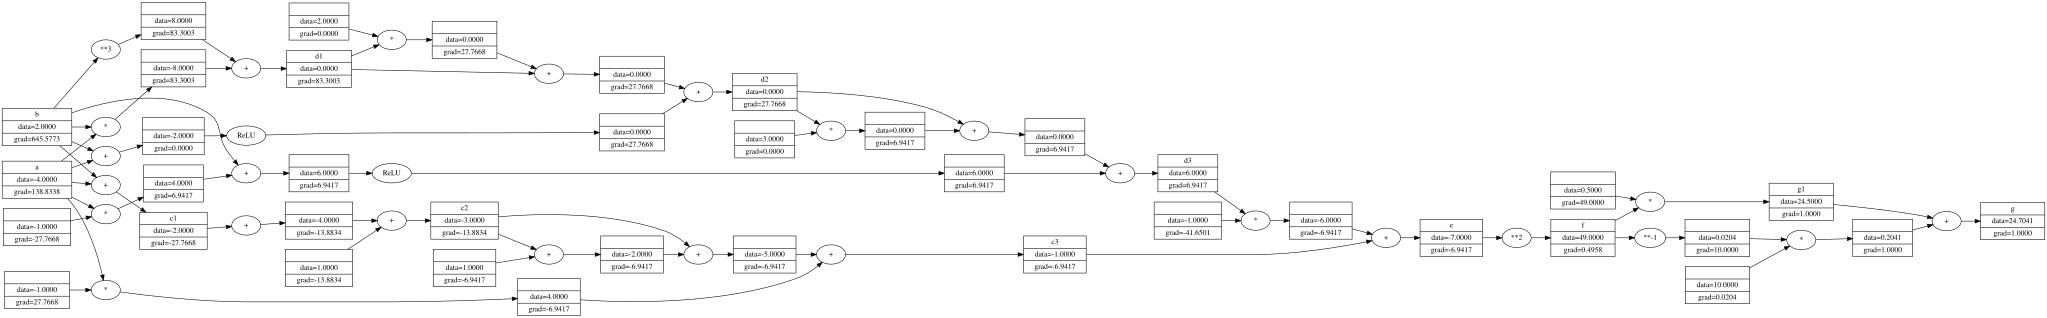

In [16]:
# Cell 3: Computation
a = Value(-4.0)
a.label = 'a'
b = Value(2.0)
b.label = 'b'

c = a + b; c.label = 'c1'
d = a * b + b**3; d.label = 'd1'

c = c + c + 1; c.label = 'c2'
c = c + 1 + c + (-a); c.label = 'c3'

d = d + d * 2 + (b + a).relu(); d.label = 'd2'
d = d + 3 * d + (b - a).relu(); d.label = 'd3'

e = c - d; e.label = 'e'
f = e**2; f.label = 'f'
g = f / 2.0; g.label = 'g1'
g = g + 10.0 / f; g.label = 'g'

g.backward()
draw_dot(g)